# Lab 9

# Sydney Golden

#Part 1

Clearly state the question under your project topic and explain why this is interesting to analyze. Prepare an appropriate dataset for clustering. List and explain the variables included in the clustering analysis. If variables are measured on different scales, standardize the variables.

# Question: Can we set up partitions to identify currency types based on the variables of salary and the salary:USD salary ratio?

This question will be interesting to analyze to understand the value of difference currencies in countries in comparison to our our salary in USD. It can help paint a broader picture of the economic statuses of other countries. Also, it will be interesting to see if K-cluster is able to make identifications off of only a few variables.

**Variables:**

*   Salary - Used to create salary ratio
*   Salary in  USD - Used to create salary ratio
*   Salary Currency - EUR, CAD, USD

**Derived Variables**

*   Salary Ratio - Salary/Salary in USD









In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage

In [44]:
# Load the merged dataset
df = pd.read_csv("https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_salaries_clean.csv")
print("Dataset Preview:")
df.head()

Dataset Preview:


,ID,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
4,5,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


The cleanned data set will only need salary, salary in USD in salary currency to answer our question

In [45]:

df = df[['salary','salary_in_usd','salary_currency']]

Salary ratio is the base salary divided by the salary in USD. This means that if the ratio is greater than 1, the currency is weaker to the US's. If it is less than 1, the salary is stronger than the USD.

In [46]:
df['salary_ratio'] = df['salary'] / df['salary_in_usd']

The currencies we are observing include the Euro (EUR), Canadian Dollar (CAD), and the British Pound (GBP).

In [47]:
df = df.loc[(df['salary_currency'] == 'EUR') | (df['salary_currency'] == 'CAD') | (df['salary_currency'] == 'GBP')]
df.reset_index()

,index,salary,salary_in_usd,salary_currency,salary_ratio
0,3,20000,22809,EUR,0.876847
1,4,43200,49268,EUR,0.876837
2,5,157000,117104,CAD,1.340689
3,6,48000,54742,EUR,0.876840
4,8,51999,59303,EUR,0.876836
...,...,...,...,...,...
521,3149,35000,37558,EUR,0.931892
522,3177,62000,75344,GBP,0.822892
523,3178,52000,63192,GBP,0.822889
524,3181,48000,58331,GBP,0.822890


The EUR and GBP currencies have a salary ratio below 1, meaning that those currencies were stronger than the USD in those years. CAD has a ratio of over 1, indicating that is was weaker than the USD at the time of data collection.

In [48]:
df['salary_currency'].value_counts()

,count
salary_currency,
EUR,295
GBP,188
CAD,43


It's important to understand the range of inputs before starting analysis. There are many more salary currency values for EUR and GBP than CAD.

In [49]:
# Shape
clean = df[['salary','salary_ratio']]
clean.shape

(526, 2)

In [50]:
# Scale the data
scaler = StandardScaler()
scaled = scaler.fit_transform(clean)

# Part 2

Run K-means clustering using several possible values of K and justify your choices. Examine the clustering result using the elbow method or silhouette scores and discuss whether the number of groups is meaningful under the data and question context.


First, we'll try K = 3 since we have thre distinct currency groups in our data set including EUR, CAD and USD.

In [51]:
# K means on scaled data
kmeans = KMeans(n_clusters=3, # Setting K = 3 because we expect to have 3 currency groups
                random_state=2,
                n_init=20).fit(scaled)

In [52]:
kmeans.labels_

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1,
       0, 0, 0, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2, 0, 1, 2, 1, 2, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 2, 0, 1, 0, 1, 1, 2, 1, 1, 1, 2, 2, 2, 1,
       1, 1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       0, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 0, 0, 1, 1, 2, 1, 1, 2, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 0, 2, 0, 0, 1, 0, 1, 1, 2, 0,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2,
       1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2,
       1, 0, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 1, 1, 2, 2, 1, 0, 1, 2, 2, 0, 1, 1, 0, 1, 1, 2, 2, 1, 1, 2,
       1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 2, 2, 2,
       2, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 1, 2, 1,

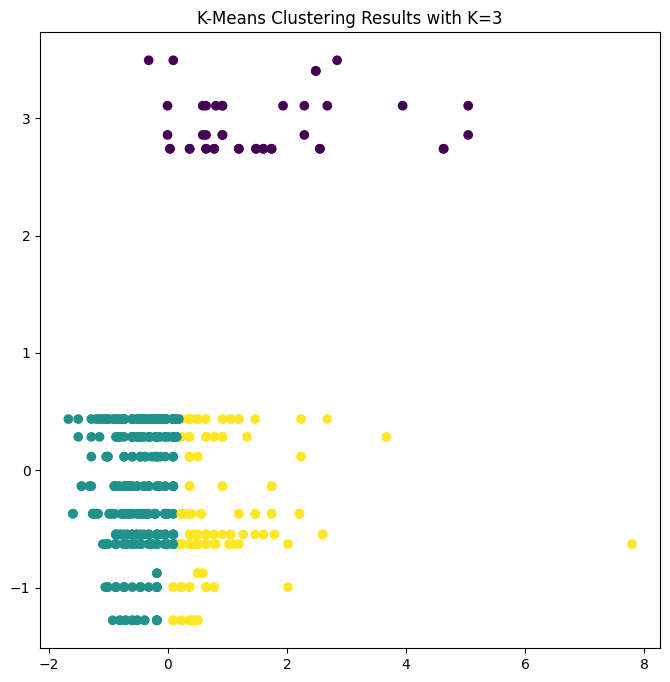

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(scaled[:,0], scaled[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=3");

K = 3 has properly identified 3 distinct groups of clusters based on our variables

Let's try a K value that would create too many groups. We'll try K = 5 to see if the outcome changes.

In [54]:
# K means on scaled data
kmeans2 = KMeans(n_clusters=5, # K = 5
                random_state=2,
                n_init=20).fit(scaled)

In [55]:
kmeans2.labels_

array([0, 0, 1, 0, 2, 2, 0, 2, 2, 0, 4, 0, 0, 2, 4, 2, 0, 0, 4, 0, 0, 2,
       0, 4, 0, 4, 2, 0, 2, 4, 0, 0, 4, 0, 1, 2, 2, 0, 2, 2, 0, 4, 0, 0,
       2, 0, 4, 0, 0, 0, 2, 0, 4, 2, 0, 0, 0, 4, 0, 0, 4, 4, 0, 0, 4, 0,
       1, 1, 1, 0, 4, 0, 0, 0, 0, 0, 4, 4, 4, 4, 3, 0, 4, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 4, 1, 0, 1, 0, 0, 4, 0, 0, 0, 4, 4, 4, 0,
       0, 0, 0, 1, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 1, 0, 4, 0, 4, 0, 4, 0,
       3, 4, 4, 4, 0, 0, 4, 0, 0, 4, 0, 1, 1, 0, 0, 4, 0, 0, 4, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 4, 4, 4, 0, 1, 4, 1, 1, 0, 1, 0, 0, 0, 1,
       4, 4, 0, 0, 0, 0, 0, 0, 0, 4, 0, 2, 2, 2, 4, 2, 2, 2, 4, 2, 2, 4,
       0, 4, 0, 2, 2, 2, 2, 2, 3, 0, 2, 2, 2, 2, 2, 4, 2, 0, 0, 2, 2, 4,
       0, 1, 4, 2, 2, 2, 2, 4, 0, 4, 4, 0, 2, 2, 2, 0, 0, 4, 0, 2, 2, 2,
       0, 0, 0, 2, 4, 4, 2, 1, 0, 4, 4, 3, 2, 2, 1, 2, 2, 4, 2, 0, 0, 4,
       2, 2, 2, 2, 2, 2, 4, 4, 2, 2, 4, 0, 4, 0, 2, 4, 4, 2, 2, 4, 4, 2,
       4, 0, 0, 4, 0, 2, 2, 0, 2, 4, 2, 2, 2, 4, 0,

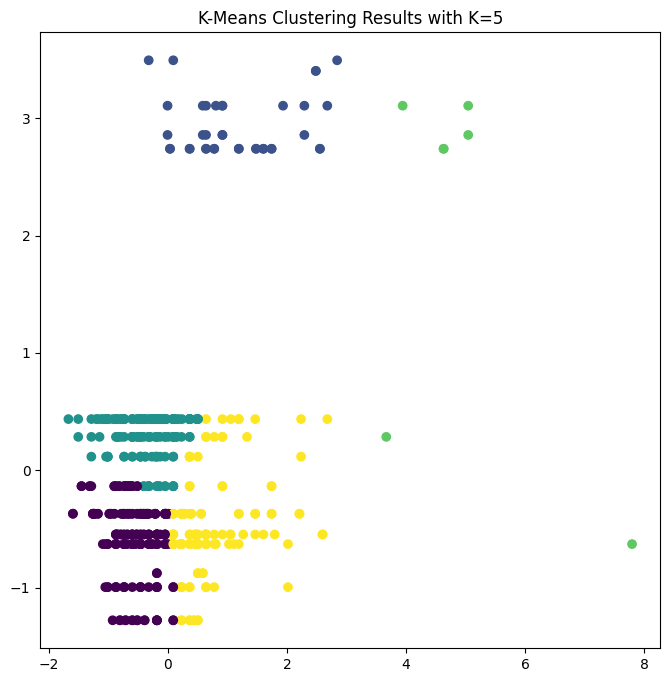

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(scaled[:,0], scaled[:,1], c=kmeans2.labels_)
ax.set_title("K-Means Clustering Results with K=5");

K = 5 did result in 5 distinct groups. Some of the outliers in the other group were identified as a light green instead of yellow.

Finally, we'll try K = 2 to see how clustering reacts when there are too little groups.

In [57]:
# K means on scaled data
kmeans3 = KMeans(n_clusters=2, # K = 2
                random_state=2,
                n_init=20).fit(scaled)

In [58]:
kmeans3.labels_

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

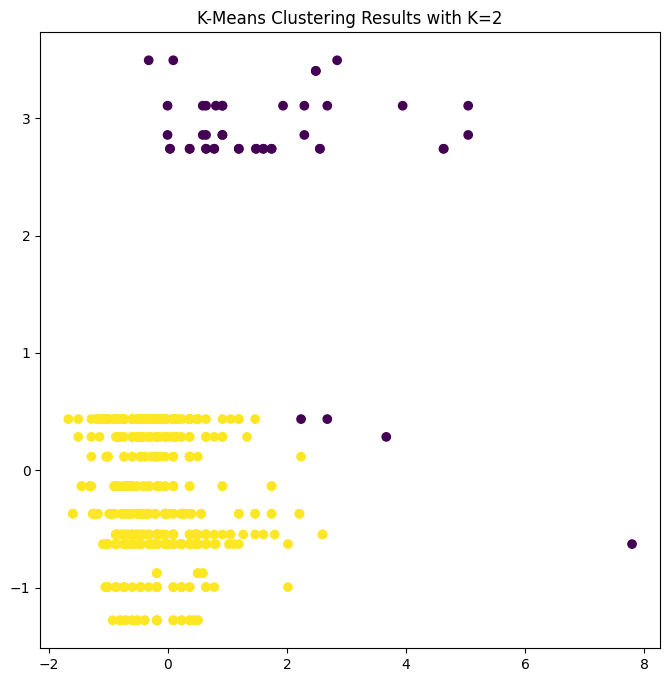

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(scaled[:,0], scaled[:,1], c=kmeans3.labels_)
ax.set_title("K-Means Clustering Results with K=2");

K = 2 does not have as many distinct groups as the others. There are purple points towards the bottom of the plot around the yellow points instead of at the top of the plot, indicating there may be another possible gorup.

In [60]:
# Silhouette and Elbow scores

from sklearn.metrics import silhouette_score

# Compare several possible values of K
K_elbow = range(1, 11)
K_silhouette = range(2, 11)

inertias = []
silhouette_scores = []

for k in K_elbow:
    kmeans = KMeans(n_clusters=k,
                    random_state=2,
                    n_init=20).fit(scaled)
    inertias.append(kmeans.inertia_)

for k in K_silhouette:
    kmeans = KMeans(n_clusters=k,
                    random_state=2,
                    n_init=20).fit(scaled)
    silhouette_scores.append(silhouette_score(scaled, kmeans.labels_))

k_summary = pd.DataFrame({
    'K': list(K_elbow),
    'Inertia': inertias,
    'Silhouette Score': [np.nan] + silhouette_scores
})

k_summary

,K,Inertia,Silhouette Score
0,1,1052.000000,NaN
1,2,511.101778,0.704401
2,3,362.858959,0.417450
3,4,273.537398,0.404252
4,5,211.999107,0.389502
5,6,167.159212,0.399974
6,7,138.586914,0.404298
7,8,115.150527,0.402554
8,9,96.984774,0.406575
9,10,84.808219,0.387171


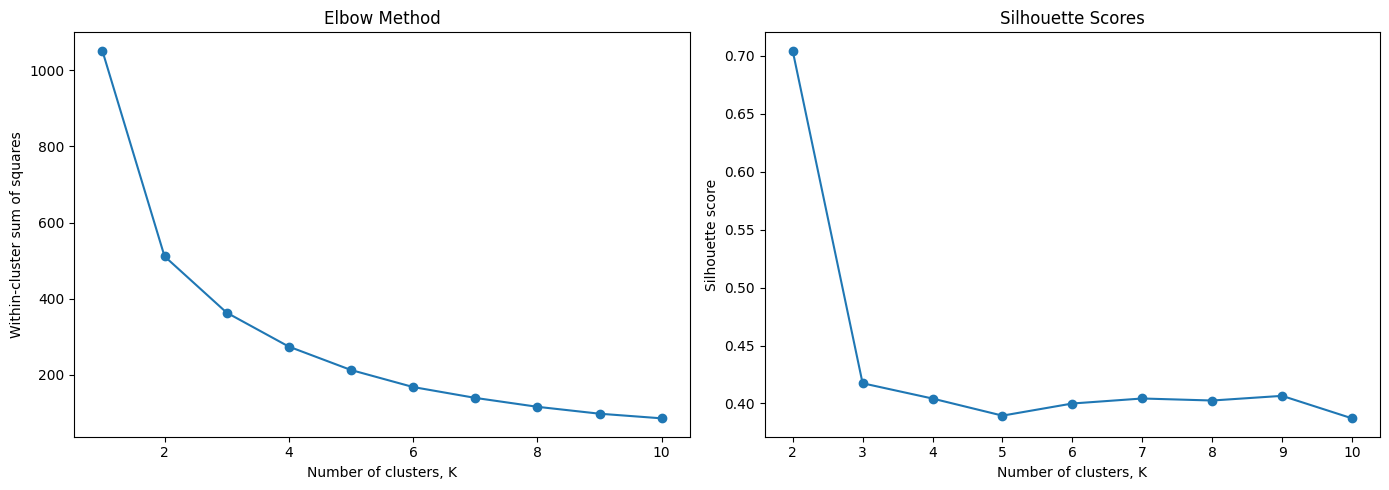

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax[0].plot(list(K_elbow), inertias, marker='o')
ax[0].set_xlabel("Number of clusters, K")
ax[0].set_ylabel("Within-cluster sum of squares")
ax[0].set_title("Elbow Method")

# Silhouette plot
ax[1].plot(list(K_silhouette), silhouette_scores, marker='o')
ax[1].set_xlabel("Number of clusters, K")
ax[1].set_ylabel("Silhouette score")
ax[1].set_title("Silhouette Scores")

plt.tight_layout();

According to the silhoutte and elbow scores, K = 3 still seems like a reasonable amount of clusters. K = 3 is where the trend begins to slow down in the elbow score plot, and has the largest silhouette score out of the possible values.

# Part 3

Apply hierarchical clustering to the same standardized dataset from Part 2. Use at least two different linkage methods. Create dendrograms for the hierarchical clustering results. Interpret the dendrogram and choose a reasonable number of clusters based on your project context.

Complete Linkage

In [62]:
# Complete Linkage

HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0,
                 n_clusters=None,
                 linkage='complete')
hc_comp.fit(scaled)

AgglomerativeClustering(distance_threshold=0, linkage='complete',
                        n_clusters=None)

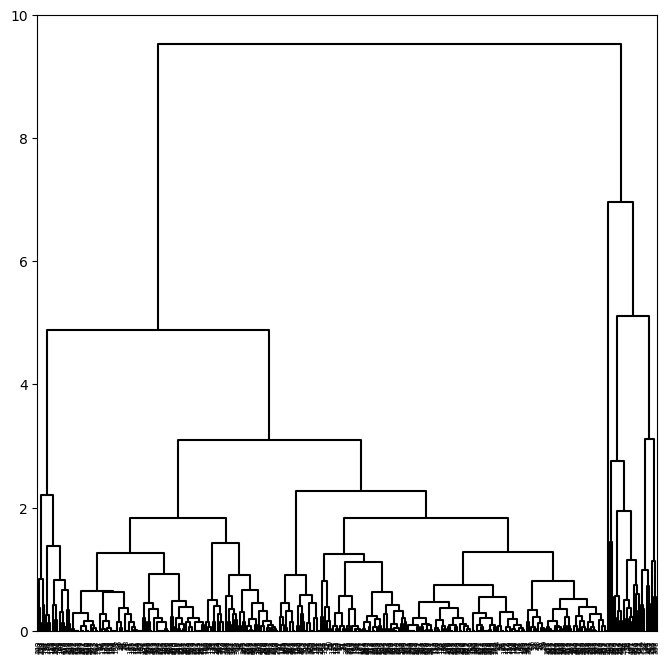

In [63]:
cargs = {'color_threshold':-np.inf,
         'above_threshold_color':'black'}
linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_comp,
           ax=ax,
           **cargs);


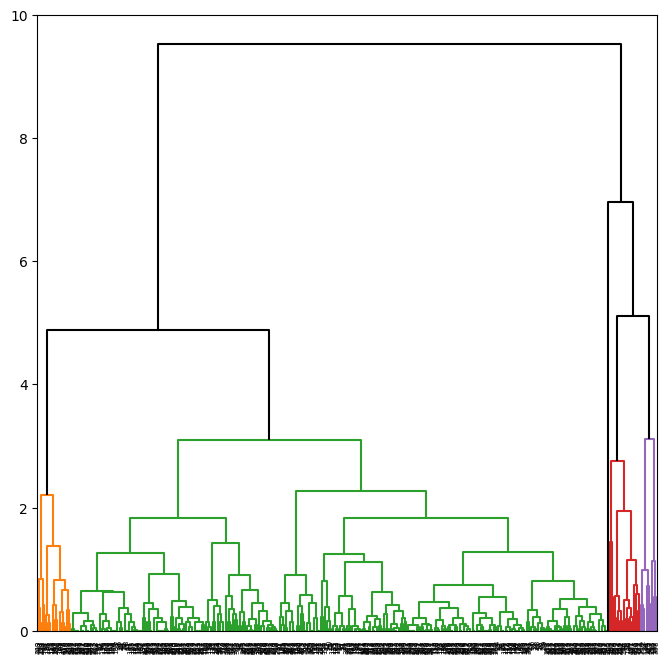

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_comp,
           ax=ax,
           color_threshold=4,
           above_threshold_color='black');

For the above complete linkage dendrogram, a line drawn at y = 4 will cross 4 colors. This indicates that the model found 4 different clusters. This is somewhat different than the original prediction, which was assumed to be 3 clusters.

Average Linkage

In [65]:
# Average Linkage
hc_avg = HClust(distance_threshold=0,
                n_clusters=None,
                linkage='average');
hc_avg.fit(scaled)


AgglomerativeClustering(distance_threshold=0, linkage='average',
                        n_clusters=None)

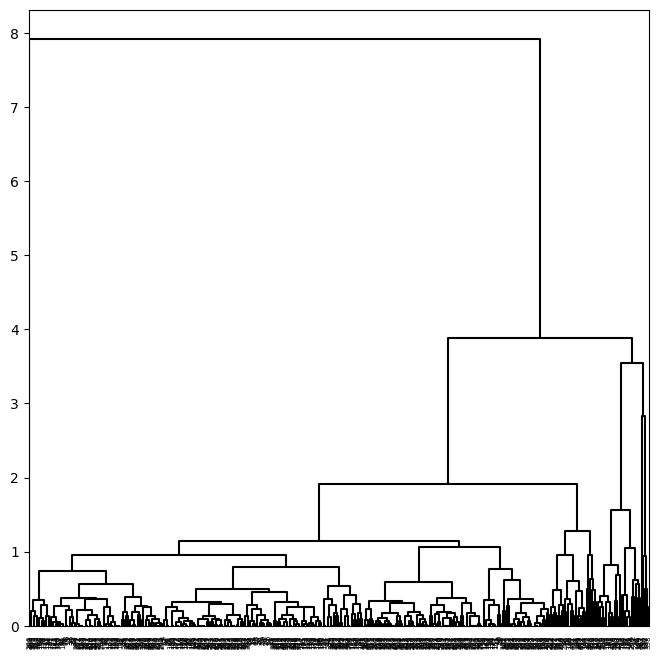

In [66]:
cargs = {'color_threshold':-np.inf,
         'above_threshold_color':'black'}
linkage_avg = compute_linkage(hc_avg)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_avg,
           ax=ax,
           **cargs);

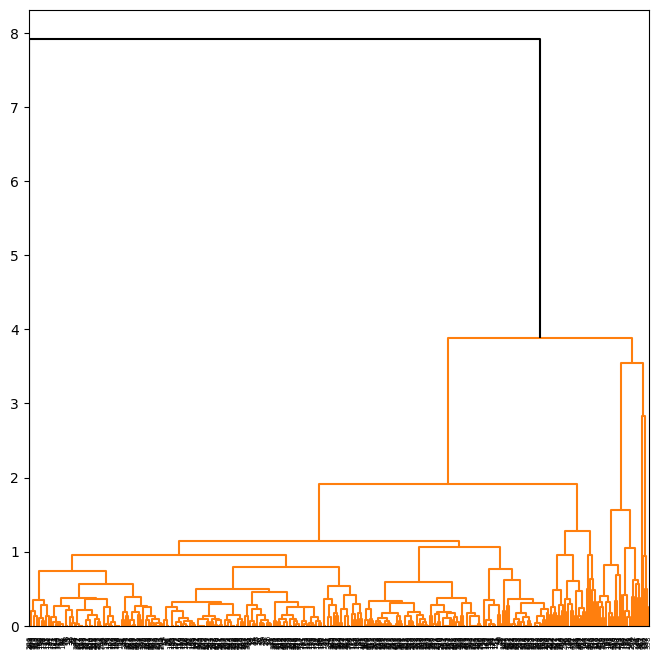

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_avg,
           ax=ax,
           color_threshold=4,
           above_threshold_color='black');

At y = 4, two lines will be crossed indicating that the average found two cluster groups.

Based on the original project context, we will stick to 3 clusters to identify the three different currency groups (EUR, CAD, and USD).

In [68]:
linkage_comp = compute_linkage(hc_comp)
comp_cut = cut_tree(linkage_comp, n_clusters=3).reshape(-1)
pd.crosstab(df['salary_currency'],
            pd.Series(comp_cut.reshape(-1), name='Complete Linkage'))

Complete Linkage,0,1
salary_currency,,
CAD,15,2
EUR,109,11
GBP,27,1


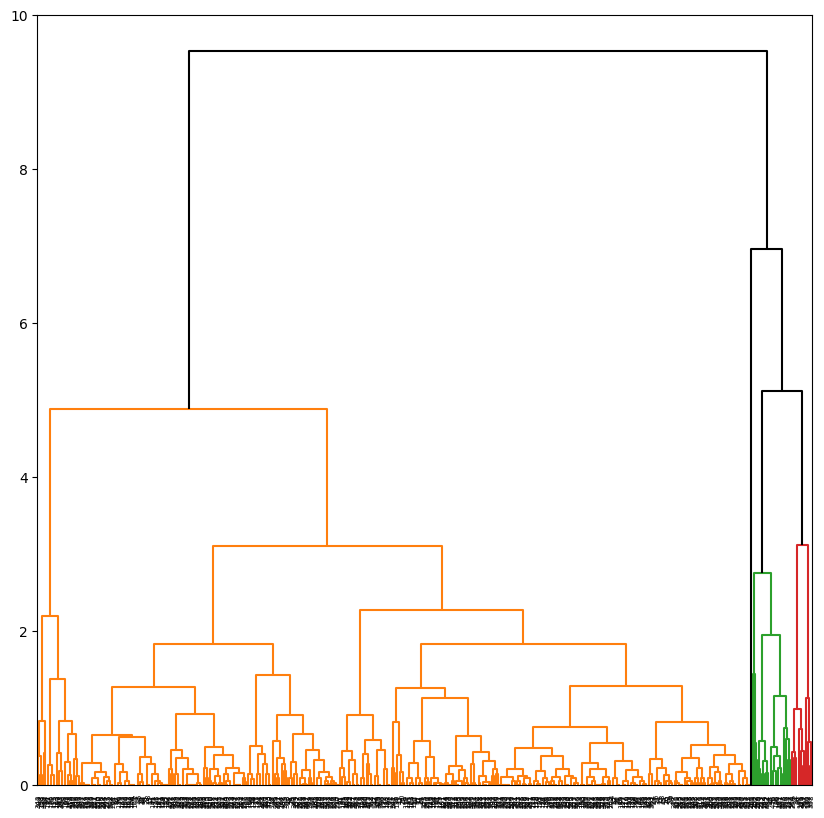

In [70]:
fig, ax = plt.subplots(figsize=(10,10))

linkage_comp = compute_linkage(hc_comp)
dendrogram(linkage_comp,
           ax=ax,
           color_threshold=5,
           above_threshold_color='black')

ax.axhline(140, c='r', linewidth=4)